In [6]:
import pandas as pd

file_path = 'D:/healthcare_iot_expanded_timeseries.csv'
df = pd.read_csv(file_path)

# Check initial data info and preview
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                10000 non-null  int64  
 1   Timestamp                 10000 non-null  object 
 2   Sensor_ID                 10000 non-null  int64  
 3   Sensor_Type               10000 non-null  object 
 4   Temperature (°C)          10000 non-null  float64
 5   Systolic_BP (mmHg)        10000 non-null  float64
 6   Diastolic_BP (mmHg)       10000 non-null  float64
 7   Heart_Rate (bpm)          10000 non-null  float64
 8   Device_Battery_Level (%)  10000 non-null  float64
 9   Target_Blood_Pressure     10000 non-null  float64
 10  Target_Heart_Rate         10000 non-null  float64
 11  Target_Health_Status      10000 non-null  object 
 12  Battery_Level (%)         10000 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 1015.8+ KB


,Patient_ID,Timestamp,Sensor_ID,Sensor_Type,Temperature (°C),Systolic_BP (mmHg),Diastolic_BP (mmHg),Heart_Rate (bpm),Device_Battery_Level (%),Target_Blood_Pressure,Target_Heart_Rate,Target_Health_Status,Battery_Level (%)
0,4840,2024-01-01 00:00:00,2,Heart Rate,36.989953,121.546299,80.947722,99.105350,95.977708,120.0,80.0,Unhealthy,80.995001
1,1863,2024-01-01 01:00:00,4,Blood Pressure,37.417925,142.468778,89.144288,98.959472,85.990909,120.0,80.0,Unhealthy,83.990830
2,9666,2024-01-01 02:00:00,4,Heart Rate,36.556896,142.142116,89.663808,65.162788,80.969081,140.0,80.0,Healthy,86.980877
3,7668,2024-01-01 03:00:00,4,Battery,36.789636,92.992193,59.660606,88.869335,95.952890,140.0,70.0,Unhealthy,82.971836
4,4561,2024-01-01 04:00:00,3,Battery,37.566502,138.747710,88.284090,87.751473,86.975241,140.0,90.0,Unhealthy,84.998281


In [7]:
# Convert Timestamp to datetime and sort
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(['Patient_ID', 'Timestamp']).reset_index(drop=True)

# Forward-fill and backward-fill missing values per Patient_ID on key numerical columns
num_cols = ['Temperature (°C)', 'Systolic_BP (mmHg)', 'Diastolic_BP (mmHg)', 'Heart_Rate (bpm)', 
            'Device_Battery_Level (%)', 'Battery_Level (%)', 'Target_Blood_Pressure', 'Target_Heart_Rate']
for col in num_cols:
    df[col] = df.groupby('Patient_ID')[col].transform(lambda x: x.ffill().bfill())

# Drop any remaining rows with missing values
df = df.dropna()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Patient_ID                10000 non-null  int64         
 1   Timestamp                 10000 non-null  datetime64[ns]
 2   Sensor_ID                 10000 non-null  int64         
 3   Sensor_Type               10000 non-null  object        
 4   Temperature (°C)          10000 non-null  float64       
 5   Systolic_BP (mmHg)        10000 non-null  float64       
 6   Diastolic_BP (mmHg)       10000 non-null  float64       
 7   Heart_Rate (bpm)          10000 non-null  float64       
 8   Device_Battery_Level (%)  10000 non-null  float64       
 9   Target_Blood_Pressure     10000 non-null  float64       
 10  Target_Heart_Rate         10000 non-null  float64       
 11  Target_Health_Status      10000 non-null  object        
 12  Battery_Level (%)  

In [8]:
# Extract time components
df['hour'] = df['Timestamp'].dt.hour
df['dayofweek'] = df['Timestamp'].dt.dayofweek

# Rolling averages for 3-period window per patient
df['Heart_Rate_Rolling_Mean_3'] = df.groupby('Patient_ID')['Heart_Rate (bpm)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df['Systolic_BP_Rolling_Mean_3'] = df.groupby('Patient_ID')['Systolic_BP (mmHg)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df['Diastolic_BP_Rolling_Mean_3'] = df.groupby('Patient_ID')['Diastolic_BP (mmHg)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df['Temperature_Rolling_Mean_3'] = df.groupby('Patient_ID')['Temperature (°C)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Rate of change features
df['Heart_Rate_Change'] = df.groupby('Patient_ID')['Heart_Rate (bpm)'].diff().fillna(0)
df['Systolic_BP_Change'] = df.groupby('Patient_ID')['Systolic_BP (mmHg)'].diff().fillna(0)
df['Diastolic_BP_Change'] = df.groupby('Patient_ID')['Diastolic_BP (mmHg)'].diff().fillna(0)

# Flags for abnormal vitals
df['High_Heart_Rate'] = (df['Heart_Rate (bpm)'] > 100).astype(int)
df['High_Systolic_BP'] = (df['Systolic_BP (mmHg)'] > 140).astype(int)
df['High_Diastolic_BP'] = (df['Diastolic_BP (mmHg)'] > 90).astype(int)


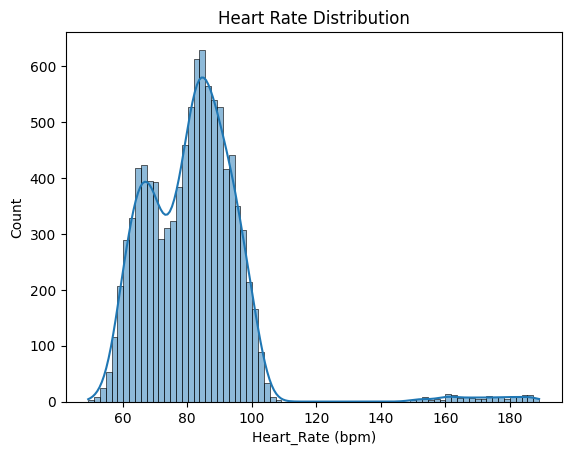

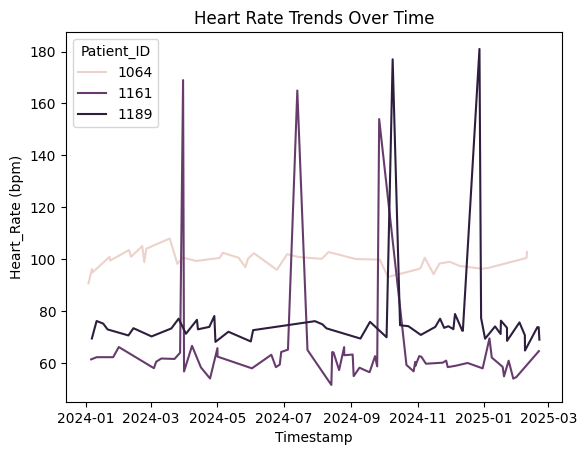

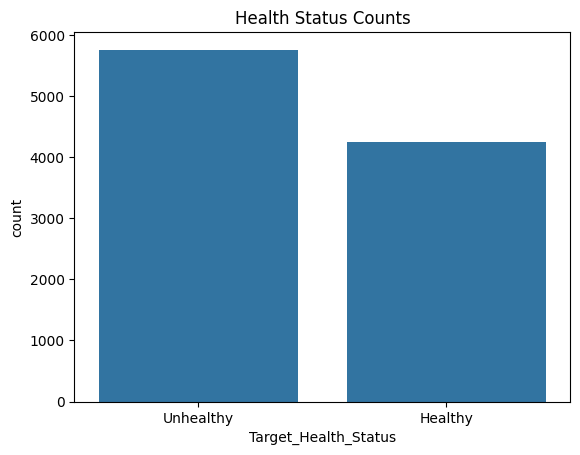

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Heart Rate
sns.histplot(df['Heart_Rate (bpm)'], kde=True)
plt.title('Heart Rate Distribution')
plt.show()

# Time series trend example for a few patients
sample_patients = df['Patient_ID'].unique()[:3]
sns.lineplot(data=df[df['Patient_ID'].isin(sample_patients)], x='Timestamp', y='Heart_Rate (bpm)', hue='Patient_ID')
plt.title('Heart Rate Trends Over Time')
plt.show()

# Health status count
sns.countplot(x='Target_Health_Status', data=df)
plt.title('Health Status Counts')
plt.show()


In [11]:
from sklearn.ensemble import IsolationForest

# Select features for anomaly detection
feature_cols = ['Heart_Rate (bpm)', 'Systolic_BP (mmHg)', 'Diastolic_BP (mmHg)', 'Temperature (°C)']

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)

# Mark anomaly (outlier) as True, normal as False
df['anomaly'] = df['anomaly'] == -1

# Count anomalies
print(df['anomaly'].value_counts())


anomaly
False    9500
True      500
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Map health status to binary labels
df['Health_Label'] = df['Target_Health_Status'].map({'Healthy': 0, 'Unhealthy': 1})

X = df[feature_cols + ['hour', 'dayofweek']]
y = df['Health_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.61      0.56      0.59       823
           1       0.71      0.75      0.73      1177

    accuracy                           0.67      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.67      0.67      0.67      2000

